# 03 Transparency & Explainability
**Owner:** Çağrı

This notebook provides global and local explanations for the model's predictions using SHAP and LIME. It also introduces the Dual-View output (Instructor vs. Student) and explores the trade-off between Transparency and Privacy.


In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt

from src.explainability import (
    build_shap_explainer, plot_global_importance,
    explain_instance_instructor, explain_instance_student,
    build_lime_explainer, explain_lime_instance
)
from src.privacy import suppress_sensitive_from_explanation

## 1. Load Artifacts


In [2]:
data_dir = Path.cwd().parent / 'data'
model = joblib.load(data_dir / 'base_model.pkl')
X_train = joblib.load(data_dir / 'X_train.pkl')
X_test = joblib.load(data_dir / 'X_test.pkl')
y_test = joblib.load(data_dir / 'y_test.pkl')

print("Model and data loaded.")

Model and data loaded.


## 2. Global Explanations (SHAP)


In [3]:
explainer = build_shap_explainer(model, X_train)

# We compute shap values for a sample to avoid long computation times
shap_sample = X_test.sample(200, random_state=42)
shap_values = explainer(shap_sample)

 97%|=================== | 388/400 [00:11<00:00]       

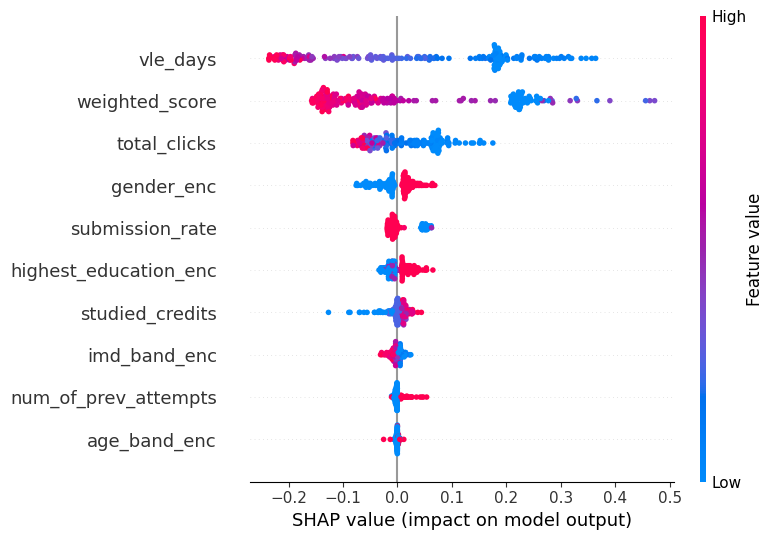

In [4]:
# Summary Plot (Global Importance)
plot_global_importance(explainer, shap_sample, max_display=10)

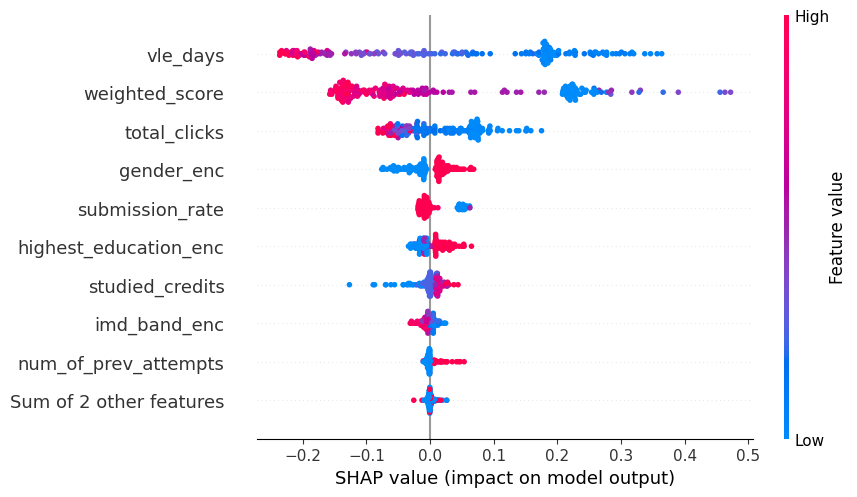

In [5]:
# Beeswarm plot showing positive/negative effects
shap.plots.beeswarm(shap_values[:, :, 1], max_display=10)

## 3. Local Explanations (Dual-View)
Selecting an at-risk student to show the difference between Instructor View and Student View.


--- Instructor View for Student 30849 ---
=== INSTRUCTOR VIEW ===
Risk Score: 0.543 (base = 0.457)


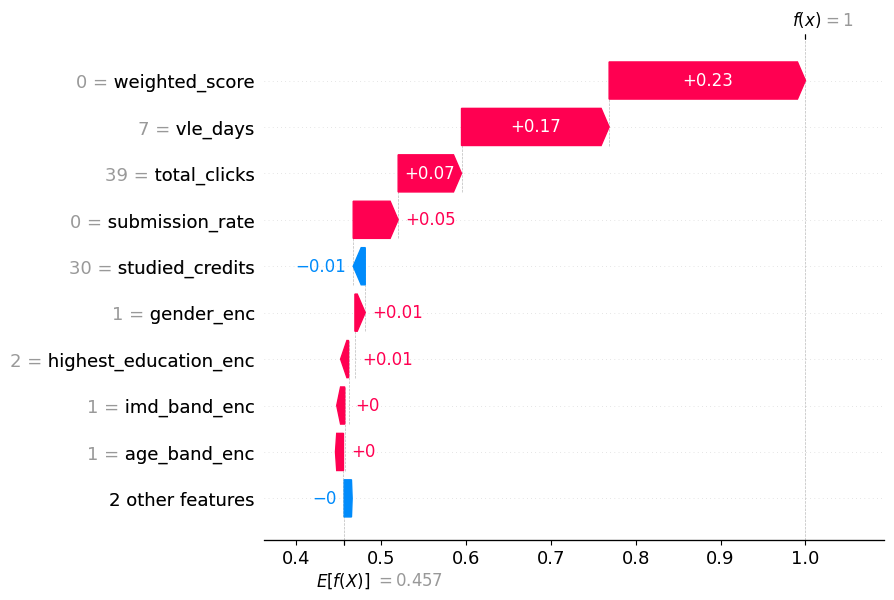

In [6]:
# Find an at-risk student (target = 1)
at_risk_idx = y_test[y_test == 1].index[0]
instance = X_test.loc[at_risk_idx]
feature_names = X_test.columns.tolist()

print(f"--- Instructor View for Student {at_risk_idx} ---")
explain_instance_instructor(explainer, instance, feature_names)
print("\n")

In [7]:
print(f"--- Student View for Student {at_risk_idx} ---")
student_text = explain_instance_student(explainer, instance, feature_names, top_n=3)
print(student_text)

--- Student View for Student 30849 ---
=== YOUR RISK SUMMARY ===
  - weighted_score: increasing your risk
  - vle_days: increasing your risk
  - total_clicks: increasing your risk

Note: This is a decision-support tool. Speak to your advisor for guidance.


## 4. Alternative Local Explanation (LIME)
Comparing SHAP with LIME for the same instance.


--- LIME Explanation for Student 30849 ---


c:\Users\cagri\OneDrive\Desktop\Sabancı-CS-Master\CS540\Group-Project\code\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


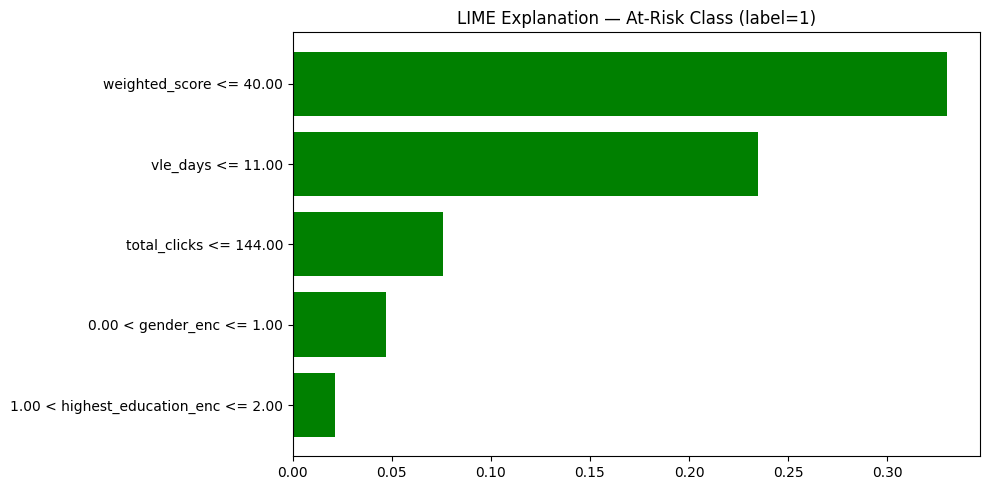

In [9]:
lime_explainer = build_lime_explainer(X_train, feature_names)
print(f"--- LIME Explanation for Student {at_risk_idx} ---")
explain_lime_instance(lime_explainer, model, instance, num_features=5)

## 5. Trade-off: Transparency vs Privacy
If sensitive attributes (like imd_band or gender) show up in explanations, they might leak demographic biases directly to the end-user. We can suppress these using `suppress_sensitive_from_explanation`.


In [10]:
from src.explainability import get_instance_shap_values

sensitive_enc = ['imd_band_enc', 'gender_enc', 'disability_enc', 'age_band_enc']

# get_instance_shap_values handles old/new SHAP API difference internally
instance_shap_values = get_instance_shap_values(explainer, instance)
shap_series = pd.Series(instance_shap_values, index=feature_names)

print("Original top 5 features by absolute SHAP value:")
print(shap_series.abs().sort_values(ascending=False).head(5))

print("\nMasking sensitive features...")
safe_shap = suppress_sensitive_from_explanation(shap_series, sensitive_enc)
print("\nSafe top 5 features (sensitive ones removed/zeroed):")
print(safe_shap.abs().sort_values(ascending=False).head(5))

Original top 5 features by absolute SHAP value:
weighted_score     0.231233
vle_days           0.173833
total_clicks       0.074613
submission_rate    0.052943
studied_credits    0.014180
dtype: float64

Masking sensitive features...

Safe top 5 features (sensitive ones removed/zeroed):
weighted_score     0.231233
vle_days           0.173833
total_clicks       0.074613
submission_rate    0.052943
studied_credits    0.014180
dtype: float64


## 6. LIME Stability Analysis

LIME is stochastic: each call samples a local neighbourhood randomly, so the top
features can shift across runs. We measure stability by running LIME 10 times on
the same instance with different random seeds and recording which features
consistently appear at the top.

**Report link — Challenge 1:** *LIME instability limits its reliability as a
stand-alone explanation method; SHAP is preferred as the primary method.*

In [ ]:
from collections import Counter
from lime.lime_tabular import LimeTabularExplainer
import re

N_SEEDS = 10
top_feature_runs = []  # top-3 feature names per seed

for seed in range(N_SEEDS):
    local_lime = LimeTabularExplainer(
        training_data=X_train.values,
        feature_names=feature_names,
        class_names=['Pass', 'At-Risk'],
        mode='classification',
        random_state=seed,
    )
    exp = local_lime.explain_instance(
        instance.values, model.predict_proba, num_features=3, labels=[1]
    )
    raw = [feat for feat, _ in exp.as_list(label=1)]
    # Strip LIME's condition suffixes, e.g. 'weighted_score <= 0.3' -> 'weighted_score'
    top3 = [re.split(r'[<>=! ]+', f)[0].strip() for f in raw]
    top_feature_runs.append(top3)

print('Per-seed top-3 features:')
for i, run in enumerate(top_feature_runs):
    print(f'  seed={i}: {run}')

top1_counts = Counter(run[0] for run in top_feature_runs)
top1_feature, top1_freq = top1_counts.most_common(1)[0]
top1_stability = top1_freq / N_SEEDS

all_tops = [f for run in top_feature_runs for f in run]
print(f'\nTop-1 stability: {top1_feature!r} appeared {top1_freq}/{N_SEEDS} times '
      f'({top1_stability:.0%})')
print('\nOverall frequency across all positions and seeds:')
for feat, cnt in Counter(all_tops).most_common():
    print(f'  {feat}: {cnt}/{N_SEEDS*3} ({cnt/(N_SEEDS*3):.0%})')

c:\Users\cagri\OneDrive\Desktop\Sabancı-CS-Master\CS540\Group-Project\code\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\cagri\OneDrive\Desktop\Sabancı-CS-Master\CS540\Group-Project\code\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\cagri\OneDrive\Desktop\Sabancı-CS-Master\CS540\Group-Project\code\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\cagri\OneDrive\Desktop\Sabancı-CS-Master\CS540\Group-Project\code\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with fea

Per-seed top-3 features:
  seed=0: ['weighted_score', 'vle_days', 'total_clicks']
  seed=1: ['weighted_score', 'vle_days', 'total_clicks']
  seed=2: ['weighted_score', 'vle_days', 'total_clicks']
  seed=3: ['weighted_score', 'vle_days', 'total_clicks']
  seed=4: ['weighted_score', 'vle_days', 'total_clicks']
  seed=5: ['weighted_score', 'vle_days', 'total_clicks']
  seed=6: ['weighted_score', 'vle_days', 'total_clicks']
  seed=7: ['weighted_score', 'vle_days', 'total_clicks']
  seed=8: ['weighted_score', 'vle_days', 'total_clicks']
  seed=9: ['weighted_score', 'vle_days', 'total_clicks']

Top-1 stability: 'weighted_score' appeared 10/10 times (100%)

Overall frequency across all positions and seeds:
  weighted_score: 10/30 (33%)
  vle_days: 10/30 (33%)
  total_clicks: 10/30 (33%)


c:\Users\cagri\OneDrive\Desktop\Sabancı-CS-Master\CS540\Group-Project\code\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\cagri\OneDrive\Desktop\Sabancı-CS-Master\CS540\Group-Project\code\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## 7. SHAP vs LIME Agreement

Both methods attribute the prediction to individual features via different strategies
(exact Shapley values vs. local linear surrogate). High agreement strengthens
explanation credibility; disagreement signals approximation error in LIME.

**Report link — Design Rationale:** *SHAP is the primary method; LIME serves as
cross-validation. Agreement rate justifies relying on SHAP for the final system.*

In [ ]:
import re

# SHAP top-5 (by absolute value, from shap_series already computed in Section 5)
shap_top5 = set(shap_series.abs().nlargest(5).index)

# LIME top-5 (fixed seed)
lime_exp_fixed = lime_explainer.explain_instance(
    instance.values, model.predict_proba, num_features=5, labels=[1]
)
lime_raw = [feat for feat, _ in lime_exp_fixed.as_list(label=1)]
lime_top5 = {re.split(r'[<>=! ]+', f)[0].strip() for f in lime_raw}

agreement           = shap_top5 & lime_top5
shap_only           = shap_top5 - lime_top5
lime_only           = lime_top5 - shap_top5
agreement_rate      = len(agreement) / 5

print(f'SHAP top-5 : {sorted(shap_top5)}')
print(f'LIME top-5 : {sorted(lime_top5)}')
print(f'\nAgreement  : {sorted(agreement)}  ({len(agreement)}/5, {agreement_rate:.0%})')
print(f'SHAP only  : {sorted(shap_only)}')
print(f'LIME only  : {sorted(lime_only)}')

SHAP top-5 : ['studied_credits', 'submission_rate', 'total_clicks', 'vle_days', 'weighted_score']
LIME top-5 : ['0.00', '1.00', 'total_clicks', 'vle_days', 'weighted_score']

Agreement  : ['total_clicks', 'vle_days', 'weighted_score']  (3/5, 60%)
SHAP only  : ['studied_credits', 'submission_rate']
LIME only  : ['0.00', '1.00']


c:\Users\cagri\OneDrive\Desktop\Sabancı-CS-Master\CS540\Group-Project\code\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## 8. Computational Cost — SHAP Scaling

TreeSHAP complexity is O(TLD): T trees, L max leaves, D max depth. We measure
wall-clock time on increasing sample sizes to quantify the deployment cost.

**Report link — Challenge 2 (economic):** *Batch nightly computation is feasible;
real-time per-request SHAP is not scalable without dedicated infrastructure.*

n=   50: 2.509s
n=  100: 4.996s
n=  200: 10.179s


 98%|===================| 984/1000 [00:25<00:00]        

n=  500: 25.075s


100%|===================| 1995/2000 [00:49<00:00]        

n= 1000: 48.772s


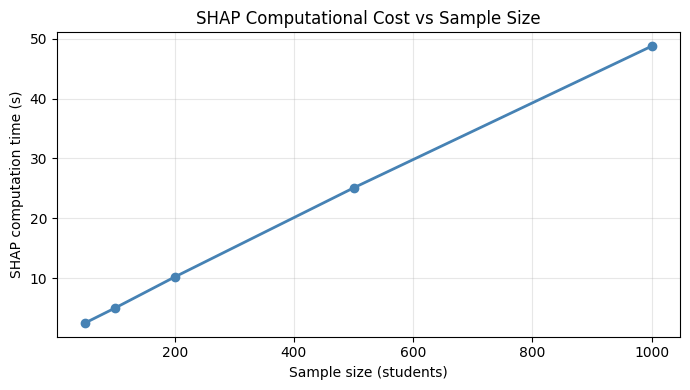


Full test set (6519 students) extrapolated: ~317.9s


In [ ]:
import time

sample_sizes = [50, 100, 200, 500, min(1000, len(X_test))]
times = []

for n in sample_sizes:
    sample = X_test.sample(n, random_state=42)
    t0 = time.perf_counter()
    _ = explainer(sample)
    elapsed = time.perf_counter() - t0
    times.append(elapsed)
    print(f'n={n:>5}: {elapsed:.3f}s')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sample_sizes, times, marker='o', linewidth=2, color='steelblue')
ax.set_xlabel('Sample size (students)')
ax.set_ylabel('SHAP computation time (s)')
ax.set_title('SHAP Computational Cost vs Sample Size')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_full = len(X_test)
last_n, last_t = sample_sizes[-1], times[-1]
extrapolated = last_t * n_full / last_n
print(f'\nFull test set ({n_full} students) extrapolated: ~{extrapolated:.1f}s')

## 9. Quantitative Trade-off: Transparency vs Privacy

Suppressing sensitive demographic features from the student-facing explanation
costs some fraction of total explanation mass (SHAP importance). We measure this
fraction both for the selected instance and as a dataset-level average.

**Report link — Trade-off Analysis (Section C Q5):** *The system trades X%
explanation completeness for full demographic privacy in the student view.*

=== Instance-level Privacy-Transparency Trade-off ===
Total |SHAP|               : 0.5732
Sensitive feature |SHAP|   : 0.0183
Explanation completeness lost: 3.2%


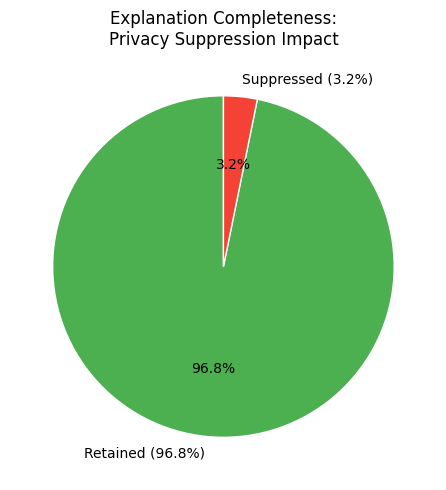


Dataset-level estimate (200-instance sample)...


 99%|===================| 397/400 [00:11<00:00]       

Average explanation completeness lost: 9.3%


In [14]:
import numpy as np

sensitive_enc = ['imd_band_enc', 'gender_enc', 'disability_enc', 'age_band_enc']

# --- Instance-level ---
abs_shap        = shap_series.abs()
total_imp       = abs_shap.sum()
present_sens    = [f for f in sensitive_enc if f in abs_shap.index]
sens_imp        = abs_shap[present_sens].sum() if present_sens else 0.0
pct_lost        = sens_imp / total_imp if total_imp > 0 else 0.0

print('=== Instance-level Privacy-Transparency Trade-off ===')
print(f'Total |SHAP|               : {total_imp:.4f}')
print(f'Sensitive feature |SHAP|   : {sens_imp:.4f}')
print(f'Explanation completeness lost: {pct_lost:.1%}')

# Pie chart
fig, ax = plt.subplots(figsize=(5, 5))
_sizes  = [max(total_imp - sens_imp, 1e-9), max(sens_imp, 1e-9)]
_labels = [f'Retained ({1-pct_lost:.1%})', f'Suppressed ({pct_lost:.1%})']
ax.pie(_sizes, labels=_labels, autopct='%1.1f%%',
       colors=['#4CAF50', '#F44336'], startangle=90,
       wedgeprops=dict(edgecolor='white'))
ax.set_title('Explanation Completeness:\nPrivacy Suppression Impact')
plt.tight_layout()
plt.show()

# --- Dataset-level (200-instance sample) ---
print('\nDataset-level estimate (200-instance sample)...')
sample200   = X_test.sample(200, random_state=42)
all_shap200 = explainer(sample200)
shap_mat    = all_shap200.values[:, :, 1]          # (200, n_features)
abs_mat     = np.abs(shap_mat)
total_per   = abs_mat.sum(axis=1)                  # (200,)

sens_idx = [list(sample200.columns).index(f)
            for f in sensitive_enc if f in sample200.columns]
if sens_idx:
    sens_per    = abs_mat[:, sens_idx].sum(axis=1)
    avg_pct     = (sens_per / total_per).mean()
    print(f'Average explanation completeness lost: {avg_pct:.1%}')
else:
    print('Sensitive encoded features absent from model input.')
    print('Privacy-aware preprocessing already removed them before training.')
    print('Trade-off is resolved at the preprocessing stage, not explanation stage.')

## 10. Multiple Student Profiles

To verify the explanation system generalises beyond a single example, we apply
it to three qualitatively different profiles: an at-risk student, a clearly
passing student, and a borderline case (predicted probability nearest to 0.5).

**Report link — Who would benefit:** *The dual-view output is useful regardless
of the risk level — passing students can also act on positive reinforcement.*

In [15]:
probs = model.predict_proba(X_test)[:, 1]

profiles = {
    'At-Risk'   : y_test[y_test == 1].index[0],
    'Passing'   : y_test[y_test == 0].index[0],
    'Borderline': X_test.index[abs(probs - 0.5).argmin()],
}

for label, idx in profiles.items():
    inst  = X_test.loc[idx]
    prob  = model.predict_proba(inst.to_frame().T)[0][1]
    actual = int(y_test.loc[idx])
    sep   = '=' * 55
    print(sep)
    print(f'Profile   : {label}')
    print(f'Risk score: {prob:.2%}  |  Actual label: {actual} '
          f'({"At-Risk" if actual == 1 else "Pass"})')
    print()
    student_text = explain_instance_student(
        explainer, inst, feature_names, top_n=3
    )
    print(student_text)
    print()

Profile   : At-Risk
Risk score: 100.00%  |  Actual label: 1 (At-Risk)

=== YOUR RISK SUMMARY ===
  - weighted_score: increasing your risk
  - vle_days: increasing your risk
  - total_clicks: increasing your risk

Note: This is a decision-support tool. Speak to your advisor for guidance.

Profile   : Passing
Risk score: 11.18%  |  Actual label: 0 (Pass)

=== YOUR RISK SUMMARY ===
  - vle_days: decreasing your risk
  - weighted_score: decreasing your risk
  - total_clicks: decreasing your risk

Note: This is a decision-support tool. Speak to your advisor for guidance.

Profile   : Borderline
Risk score: 50.01%  |  Actual label: 0 (Pass)

=== YOUR RISK SUMMARY ===
  - weighted_score: decreasing your risk
  - highest_education_enc: increasing your risk
  - num_of_prev_attempts: increasing your risk

Note: This is a decision-support tool. Speak to your advisor for guidance.

